# Chapter 5, Example 4: Computational trees, cycle-cutset conditioning, and the self-avoiding-walk tree

Tree transformations replace a loopy graph by a tree whose nodes represent copies of original variables along paths. A finite-depth computational tree describes a finite number of loopy-BP iterations. For the hard-core model, the self-avoiding-walk tree with special cycle-closing boundary conditions reproduces the exact root marginal.

In [1]:
from pathlib import Path
import math
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch05":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch05").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch05"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
})

NODE_COLOR = "#3f4c6b"
SECONDARY_NODE_COLOR = "#5b6784"
PINNED_NODE_COLOR = "#7b3f4c"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def annotate_heatmap(ax, matrix, image, fmt=".2f"):
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", color=color, fontsize=13)


In [2]:
G = nx.Graph()
G.add_edges_from([(0,1),(1,2),(2,3),(3,0),(0,2)])
root=0
neighbor_order={v: sorted(G.neighbors(v)) for v in G.nodes()}

def exact_hard_core_ratio(graph, root, activity):
    nodes=list(graph.nodes())
    Z0=Z1=0.0
    for bits in product([0,1], repeat=len(nodes)):
        state=dict(zip(nodes,bits))
        if any(state[u] and state[v] for u,v in graph.edges()):
            continue
        weight=activity**sum(bits)
        if state[root]: Z1+=weight
        else: Z0+=weight
    return Z1/Z0

def computational_tree(graph, root, depth):
    T=nx.DiGraph()
    root_path=(root,)
    T.add_node(root_path)
    frontier=[root_path]
    for _ in range(depth):
        new=[]
        for path in frontier:
            current=path[-1]
            previous=path[-2] if len(path)>1 else None
            for nxt in graph.neighbors(current):
                if nxt==previous:
                    continue
                child=path+(nxt,)
                T.add_edge(path,child)
                new.append(child)
        frontier=new
    return T

def saw_tree(graph, root, order):
    T=nx.DiGraph()
    info={}
    root_path=(root,)
    T.add_node(root_path)
    info[root_path]={"pinned":None,"label":str(root)}
    stack=[root_path]
    while stack:
        path=stack.pop()
        current=path[-1]
        previous=path[-2] if len(path)>1 else None
        for nxt in graph.neighbors(current):
            if nxt==previous:
                continue
            child=path+(nxt,)
            T.add_edge(path,child)
            if nxt in path:
                first=path.index(nxt)
                starting_neighbor=path[first+1]
                closing_neighbor=current
                occupied=(order[nxt].index(closing_neighbor) > order[nxt].index(starting_neighbor))
                info[child]={"pinned":1 if occupied else 0,
                             "label":f"{nxt}|{'1' if occupied else '0'}"}
            else:
                info[child]={"pinned":None,"label":str(nxt)}
                stack.append(child)
    return T,info

def tree_ratio(T, info, root_path, activity):
    def rec(node):
        pin=info[node]["pinned"]
        if pin==1: return math.inf
        if pin==0: return 0.0
        result=activity
        for child in T.successors(node):
            child_ratio=rec(child)
            if math.isinf(child_ratio):
                return 0.0
            result/=1.0+child_ratio
        return result
    return rec(root_path)

CT=computational_tree(G,root,4)
SAW,info=saw_tree(G,root,neighbor_order)
print("Original nodes:",len(G),"computational-tree nodes:",len(CT),"SAW-tree nodes:",len(SAW))

Original nodes: 4 computational-tree nodes: 24 SAW-tree nodes: 16


## Figure: original graph, computational tree, and SAW tree

Saved: figs/ch05_04_tree_transformations.pdf


Saved: figs/ch05_04_tree_transformations.png


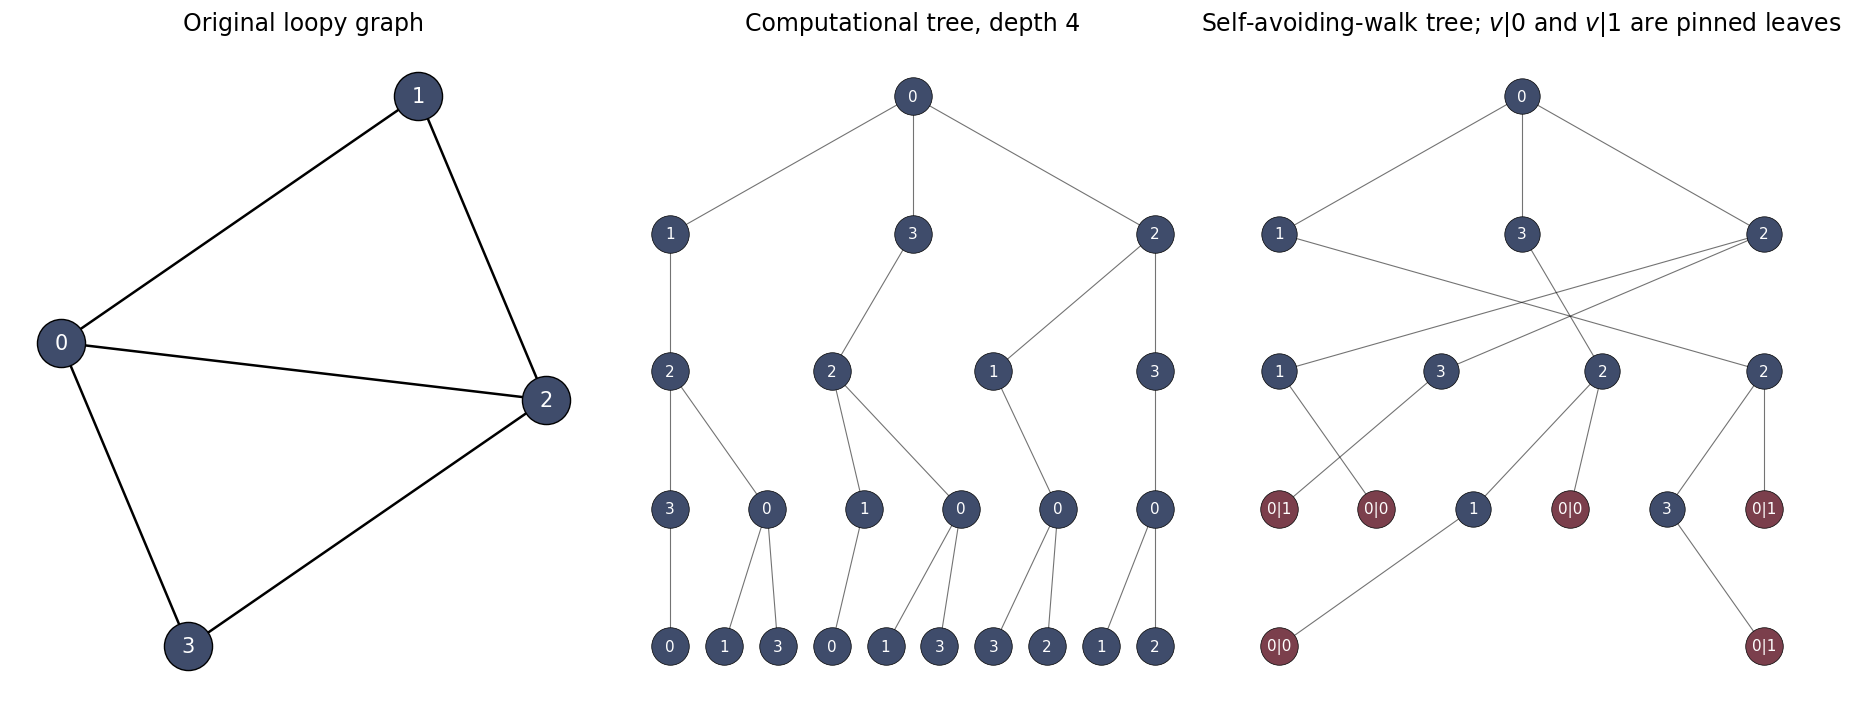

In [3]:
def hierarchy_positions(T):
    generations={}
    root_node=next(n for n in T.nodes() if T.in_degree(n)==0)
    for node in T.nodes():
        generations.setdefault(len(node)-1,[]).append(node)
    pos={}
    for level,nodes in generations.items():
        xs=np.linspace(-1,1,len(nodes)) if len(nodes)>1 else [0]
        for x,node in zip(xs,nodes):
            pos[node]=(x,-level)
    return pos

fig, axes=plt.subplots(1,3,figsize=(18.5,7.4))
posG=nx.spring_layout(G,seed=7)
nx.draw_networkx_nodes(G,posG,node_size=1200,node_color=NODE_COLOR,edgecolors="black",ax=axes[0])
nx.draw_networkx_labels(G,posG,font_color="white",font_size=15,ax=axes[0])
nx.draw_networkx_edges(G,posG,width=1.8,ax=axes[0])
axes[0].set_title("Original loopy graph")
axes[0].axis("off")

posCT=hierarchy_positions(CT)
nx.draw_networkx_nodes(CT,posCT,node_size=730,node_color=NODE_COLOR,edgecolors="black",linewidths=0.5,ax=axes[1])
nx.draw_networkx_labels(CT,posCT,labels={n:str(n[-1]) for n in CT},font_color="white",font_size=11,ax=axes[1])
nx.draw_networkx_edges(CT,posCT,width=0.8,alpha=0.55,arrows=False,ax=axes[1])
axes[1].set_title("Computational tree, depth 4")
axes[1].axis("off")

posSAW=hierarchy_positions(SAW)
free=[n for n in SAW if info[n]["pinned"] is None]
pinned=[n for n in SAW if info[n]["pinned"] is not None]
nx.draw_networkx_nodes(SAW,posSAW,nodelist=free,node_size=650,node_color=NODE_COLOR,edgecolors="black",linewidths=0.5,ax=axes[2])
nx.draw_networkx_nodes(SAW,posSAW,nodelist=pinned,node_size=730,node_color=PINNED_NODE_COLOR,edgecolors="black",linewidths=0.5,ax=axes[2])
nx.draw_networkx_labels(SAW,posSAW,labels={n:info[n]["label"] for n in SAW},font_color="white",font_size=11,ax=axes[2])
nx.draw_networkx_edges(SAW,posSAW,width=0.8,alpha=0.55,arrows=False,ax=axes[2])
axes[2].set_title("Self-avoiding-walk tree; $v|0$ and $v|1$ are pinned leaves")
axes[2].axis("off")
fig.tight_layout()
save_figure(fig,"ch05_04_tree_transformations")
plt.show()

## Exact Weitz identity for the hard-core model

For activity $\lambda$, the hard-core weight of an independent set $I$ is $\lambda^{|I|}$. On a tree, the occupied-to-unoccupied ratio obeys

$$
R_v=\lambda\prod_{u\in\operatorname{child}(v)}\frac{1}{1+R_u}.
$$

Pinned occupied leaves have ratio $+\infty$ and pinned unoccupied leaves have ratio $0$.

Maximum identity error: 5.551115123125783e-17


Saved: figs/ch05_04_saw_marginal_identity.pdf


Saved: figs/ch05_04_saw_marginal_identity.png


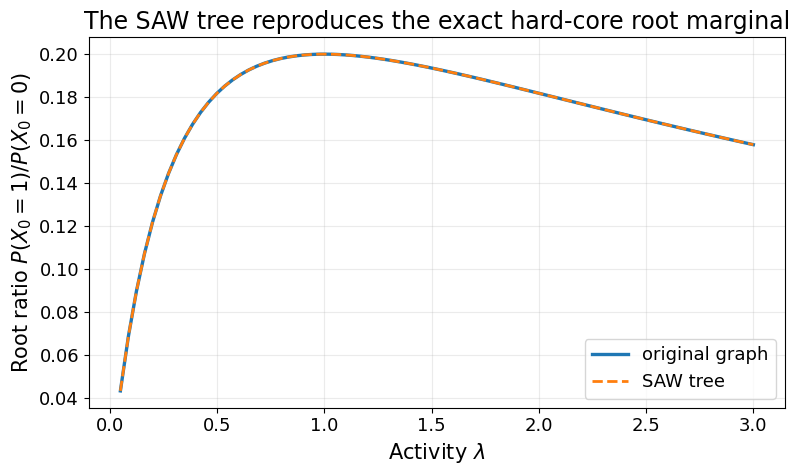

In [4]:
activities=np.linspace(0.05,3.0,80)
exact=np.array([exact_hard_core_ratio(G,root,lam) for lam in activities])
saw=np.array([tree_ratio(SAW,info,(root,),lam) for lam in activities])
print("Maximum identity error:",np.max(np.abs(exact-saw)))
assert np.allclose(exact,saw,atol=1e-12)

fig,ax=plt.subplots(figsize=(8.2,5.0))
ax.plot(activities,exact,linewidth=2.4,label="original graph")
ax.plot(activities,saw,linestyle="--",linewidth=2.0,label="SAW tree")
ax.set_xlabel(r"Activity $\lambda$")
ax.set_ylabel(r"Root ratio $P(X_0=1)/P(X_0=0)$")
ax.set_title("The SAW tree reproduces the exact hard-core root marginal")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig,"ch05_04_saw_marginal_identity")
plt.show()

## Cycle-cutset conditioning

Conditioning on node $0$ removes all cycles from this example. The partition function can therefore be computed by two tree calculations, one for $X_0=0$ and one for $X_0=1$, followed by addition.

In [5]:
def exact_partition_with_pin(graph, activity, pin=None):
    nodes=list(graph.nodes())
    total=0.0
    for bits in product([0,1],repeat=len(nodes)):
        state=dict(zip(nodes,bits))
        if pin is not None and any(state[k]!=v for k,v in pin.items()):
            continue
        if any(state[u] and state[v] for u,v in graph.edges()):
            continue
        total+=activity**sum(bits)
    return total

lam=1.35
Z0=exact_partition_with_pin(G,lam,{0:0})
Z1=exact_partition_with_pin(G,lam,{0:1})
Z=exact_partition_with_pin(G,lam)
print(f"Z(X0=0)={Z0:.6f}, Z(X0=1)={Z1:.6f}, total={Z:.6f}")
assert np.isclose(Z0+Z1,Z)

Z(X0=0)=6.872500, Z(X0=1)=1.350000, total=8.222500


## Exercises

1. Change the neighbor ordering. Verify that the pinned leaves change but the root marginal does not.
2. Increase the computational-tree depth and count how many copies of each original vertex appear.
3. Remove the diagonal edge $(0,2)$. Compare the sizes of the computational and SAW trees.
4. Implement the cycle-cutset calculation using explicit tree message passing rather than enumeration.
5. Truncate the SAW tree at a finite depth and investigate the approximation error as a function of $\lambda$.